## Utility Analysis

[Paper on using this data set for uplift modeling.](https://hal.science/hal-02515860/)

**Overview**

This file contains analysis of the utility of synthetic data sets produced using the optimized bayesian sequential synthesis and the differentially private GAN model.

A potential use case for synthetic data is to synthesize data that would otherwise be too sensitive to share, and allow companies to measure treatment efficacy conditional on those covariates.

In [160]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from scipy.stats import wasserstein_distance

num_synthetic = 20

***

Import the original and synthesized Criteo data sets.

In [161]:
# import the confidential data
original = pd.read_csv("../../Data/Criteo/cleaned_criteo_train_os.gz", 
                       compression='gzip', 
                       sep='\,',
                       header=0,
                       engine='python')

In [162]:
original

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,24.352730,10.059654,9.002550,4.679882,10.280525,4.115453,-9.404879,4.833815,3.892853,13.190056,5.300375,-0.168679,1,0,0,0
1,20.027816,10.059654,8.653796,3.359763,14.339694,4.115453,-9.864621,4.833815,3.781017,35.805995,5.916066,-0.473542,0,1,1,0
2,21.787905,10.059654,8.440707,4.679882,10.280525,4.115453,-8.493011,4.833815,3.842828,29.214161,5.300375,-0.168679,1,0,0,0
3,13.954588,10.059654,8.214851,-1.072603,10.280525,4.115453,-11.495164,4.833815,3.863287,33.213193,5.300375,-0.168679,1,1,1,1
4,23.970150,10.059654,8.214383,4.679882,10.280525,3.013064,-11.398781,10.591158,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,24.941363,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61157,23.106934,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61158,25.975578,10.059654,8.475106,4.679882,11.561050,4.115453,-2.411115,4.833815,3.835851,23.570168,6.034478,-0.168679,1,1,1,0
61159,23.131460,10.059654,8.634955,4.679882,10.280525,4.115453,-5.576414,4.833815,3.880455,16.226044,5.300375,-0.168679,1,1,1,0


In [163]:
original.loc[original.treatment==0,:]

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
1,20.027816,10.059654,8.653796,3.359763,14.339694,4.115453,-9.864621,4.833815,3.781017,35.805995,5.916066,-0.473542,0,1,1,0
9,23.716350,10.059654,8.214383,4.679882,10.280525,4.115453,-3.993764,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
14,24.455768,10.059654,8.214383,4.679882,10.280525,4.115453,-5.116672,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
25,12.616365,10.059654,8.667927,4.679882,11.029584,4.115453,0.294443,4.833815,3.840367,25.954644,6.440084,-0.168679,0,0,0,0
33,19.609479,10.059654,8.214383,3.907662,10.280525,4.115453,-8.493011,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61114,24.537085,10.059654,8.318361,4.679882,12.594889,4.115453,-7.301017,4.833815,3.809530,42.630261,5.446060,-0.473542,0,1,1,0
61127,20.768901,10.059654,8.463750,4.679882,10.280525,4.115453,-3.282109,4.833815,3.854508,26.606156,5.300375,-0.168679,0,0,0,0
61128,24.027003,10.059654,8.299383,4.679882,12.310110,3.013064,-15.588165,10.883204,3.774079,38.005580,6.019013,-0.168679,0,1,1,0
61146,22.345281,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0


***

Fit an overall model for `conversion` on the confidential data.

In [164]:
conversion_model = LogisticRegression(penalty=None, max_iter=1000)

In [165]:
X = original.drop(['conversion'], axis=1)
y = original.conversion

In [166]:
conversion_model.fit(X, y)

LogisticRegression(max_iter=1000, penalty=None)

These are the coefficients from the original model, including the intercept. We'll treat these as the 'ground truth'.

In [167]:
original_coefs = pd.Series(np.concatenate([conversion_model.intercept_, conversion_model.coef_.flatten()]))
original_coefs

0     -3.054853
1      0.018994
2     -0.601298
3     -0.560553
4     -0.088698
5      0.516033
6     -0.100959
7      0.017812
8     -0.008358
9     -1.000078
10    -0.026203
11     0.538614
12    -6.434862
13    -0.131990
14    11.502761
15     1.222432
dtype: float64

Define a function that takes a data set as input and computes the logistic regression coefficients of interest.

In [168]:
def logistic_coefs(dataset):
    # define logistic regression model
    conversion_model = LogisticRegression(penalty=None, max_iter=1000)
    # create covariates data
    X = dataset.drop(['conversion'], axis=1)
    # create outcome (target) variable
    y = dataset.conversion
    # fit model
    conversion_model.fit(X, y)
    # store coefficients
    current_coefs = pd.Series(np.concatenate([conversion_model.intercept_, conversion_model.coef_.flatten()]))
    return current_coefs

Loop over optimized synthetic data sets and compute logistic regression coefficients.

In [169]:
opt_syn_coefs = pd.DataFrame()

for i in range(num_synthetic):
    # import an optimized synthetic data set
    opt_syn_temp = pd.read_csv("../../Data/Criteo/cart_" + str(i) + "_train_os.csv")
    opt_syn_temp = opt_syn_temp[original.columns]
    current_coefs = logistic_coefs(opt_syn_temp)
    opt_syn_coefs = pd.concat([opt_syn_coefs, current_coefs], axis=1)
    print("Coefficients for data set " + str(i) + " computed.")

Coefficients for data set 0 computed.
Coefficients for data set 1 computed.
Coefficients for data set 2 computed.
Coefficients for data set 3 computed.
Coefficients for data set 4 computed.
Coefficients for data set 5 computed.
Coefficients for data set 6 computed.
Coefficients for data set 7 computed.
Coefficients for data set 8 computed.
Coefficients for data set 9 computed.
Coefficients for data set 10 computed.
Coefficients for data set 11 computed.
Coefficients for data set 12 computed.
Coefficients for data set 13 computed.
Coefficients for data set 14 computed.
Coefficients for data set 15 computed.
Coefficients for data set 16 computed.
Coefficients for data set 17 computed.
Coefficients for data set 18 computed.
Coefficients for data set 19 computed.


Add coefficient names to coefficient estimates from all synthetic data sets.

In [170]:
coef_names = pd.Series(["intercept"])
coef_names = pd.concat([coef_names, pd.Series(X.columns)], axis=0)
opt_syn_coefs.index = coef_names
opt_syn_coefs.columns = np.arange(num_synthetic)

Plot the distributions of regression coefficients for each method relative to the ground truth - the coefficient estimates from the original data.

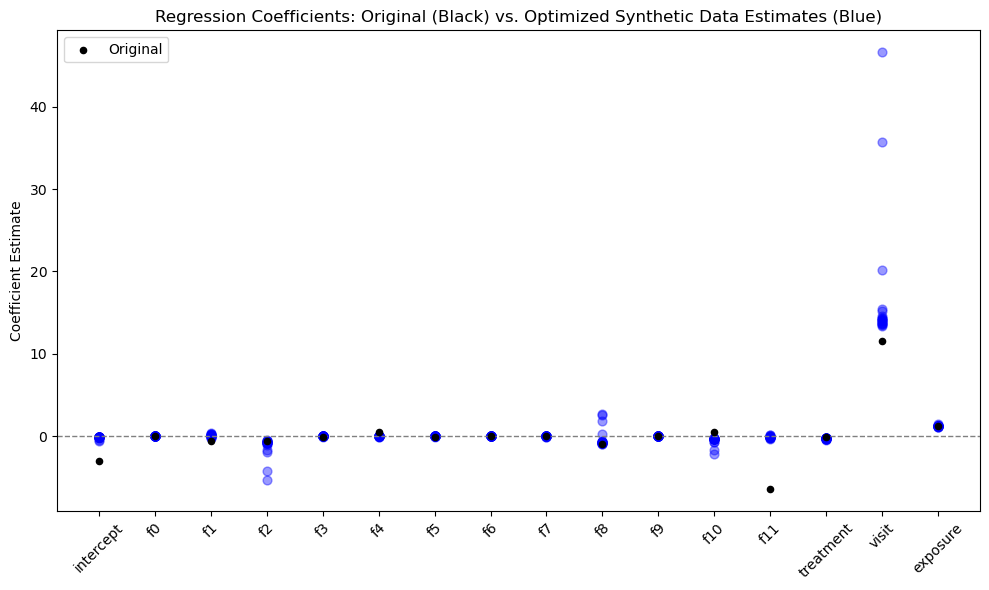

In [171]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(original_coefs))

# Baseline (black dots)
ax.scatter(x, original_coefs.values, color="black", s=num_synthetic, zorder=3, label="Original")

# Other estimates (blue dots, semi-transparent)
for col in opt_syn_coefs.columns:
    ax.scatter(x, opt_syn_coefs[col].values, color="blue", alpha=0.4, s=40)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(opt_syn_coefs.index, rotation=45)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_ylabel("Coefficient Estimate")
ax.legend()
ax.set_title("Regression Coefficients: Original (Black) vs. Optimized Synthetic Data Estimates (Blue)")

plt.tight_layout()
plt.show()

Repeat the above for the DP-GAN synthetic data sets.

In [172]:
dp_syn_coefs = pd.DataFrame()

for i in range(num_synthetic):
    # import an optimized synthetic data set
    dp_syn_temp = pd.read_csv("../../Data/Criteo/dpgan_13_" + str(i) + "_train_os.csv")
    dp_syn_temp = dp_syn_temp[original.columns]
    current_coefs = logistic_coefs(dp_syn_temp)
    dp_syn_coefs = pd.concat([dp_syn_coefs, current_coefs], axis=1)
    print("Coefficients for data set " + str(i) + " computed.")

dp_syn_coefs.index = coef_names
dp_syn_coefs.columns = np.arange(num_synthetic)

Coefficients for data set 0 computed.
Coefficients for data set 1 computed.
Coefficients for data set 2 computed.
Coefficients for data set 3 computed.
Coefficients for data set 4 computed.
Coefficients for data set 5 computed.
Coefficients for data set 6 computed.
Coefficients for data set 7 computed.
Coefficients for data set 8 computed.
Coefficients for data set 9 computed.
Coefficients for data set 10 computed.
Coefficients for data set 11 computed.
Coefficients for data set 12 computed.
Coefficients for data set 13 computed.
Coefficients for data set 14 computed.
Coefficients for data set 15 computed.
Coefficients for data set 16 computed.
Coefficients for data set 17 computed.
Coefficients for data set 18 computed.
Coefficients for data set 19 computed.


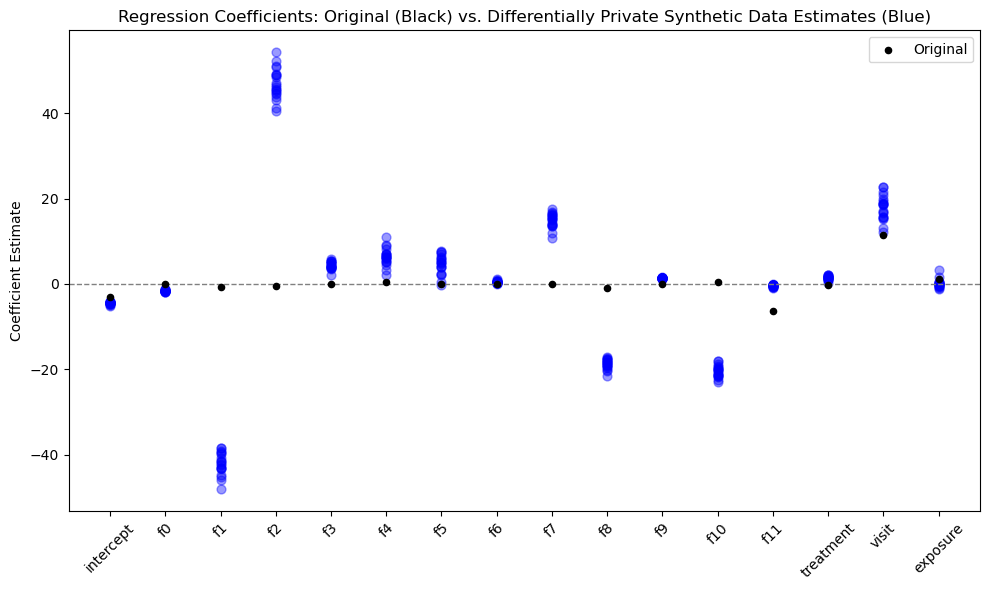

In [173]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(original_coefs))

# Baseline (black dots)
ax.scatter(x, original_coefs.values, color="black", s=num_synthetic, zorder=3, label="Original")

# Other estimates (blue dots, semi-transparent)
for col in dp_syn_coefs.columns:
    ax.scatter(x, dp_syn_coefs[col].values, color="blue", alpha=0.4, s=40)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dp_syn_coefs.index, rotation=45)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_ylabel("Coefficient Estimate")
ax.legend()
ax.set_title("Regression Coefficients: Original (Black) vs. Differentially Private Synthetic Data Estimates (Blue)")

plt.tight_layout()
plt.show()

Assuming `exposure` is the variable of interest, how do the estimates compare?

The mean of the estimates from the synthetic data sets is very close to the truth, with a small standard deviation across synthetic data sets. The DP-GAN data sets have a mean estimated effect of zero, with a much larger standard deviation.

In [174]:
print(opt_syn_coefs.loc['exposure',:].mean())
print(opt_syn_coefs.loc['exposure',:].std())

1.2307432173156627
0.07566295861747441


In [175]:
original_coefs.iloc[15]

np.float64(1.2224321989661333)

In [176]:
print(dp_syn_coefs.loc['exposure',:].mean())
print(dp_syn_coefs.loc['exposure',:].std())

0.08505907167570528
0.9473602021174035


Fit a model on the `treatment = 0` and `treatment = 1` subsets. Compute the uplift for each observation.

Diemert et al. (2018) published a paper alongside the Criteo uplift data. They discuss a two-model approach to modeling uplift, which we utilize here for one example of a use case for synthetic data.

Tasks for Ethan:

- compute uplift for observations in the original and synthetic data sets (use the two-model approach from Diemert et al. (2020))
- compare uplift distributions from the synthetic data sets to uplift distribution from the original data using
    - Wasserstein or some other distributional distance/similarity metric
    - Mean uplift
    - std. deviation uplift
    - read up on the *area under the uplift curve* (AUUC) metric from Diemert et al. (2020). Compute the AUUC for a model trained and evaluated on the original data. Compare that to AUUC values for models trained on each synthetic data set, and evaluated on the original data.

Once this workflow is established, we can repeat it for a train/test data split. We'll train the uplift models on the original/synthetic training data, and evaluate their performance using the above metrics computed on uplift distributions from the test data.


We exclude `visit` from the uplift analysis.

In [177]:
feature_cols = [f"f{i}" for i in range(12)]

In [178]:
def compute_uplift_distribution(df, feature_cols = feature_cols, treatment_col="treatment", outcome_col="conversion"):
    treat_df   = df[df[treatment_col] == 1]
    control_df = df[df[treatment_col] == 0]
    X_treat   = treat_df[feature_cols]
    y_treat   = treat_df[outcome_col]
    X_control = control_df[feature_cols]
    y_control = control_df[outcome_col]

    model_t = LogisticRegression(penalty=None, max_iter=1000)
    model_c = LogisticRegression(penalty=None, max_iter=1000)
    model_t.fit(X_treat, y_treat)
    model_c.fit(X_control, y_control)

    X_all = df[feature_cols]
    p_t = model_t.predict_proba(X_all)[:, 1]
    p_c = model_c.predict_proba(X_all)[:, 1]

    uplift = p_t - p_c
    return uplift

In [179]:
uplift_original = compute_uplift_distribution(original)

C:\Users\Cam\anaconda3\envs\optimized-sequential-synthesis\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


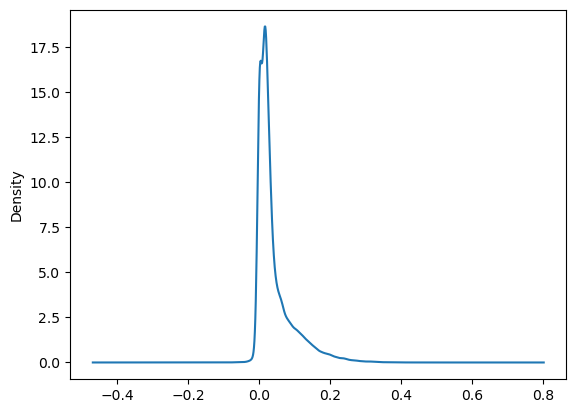

In [180]:
s = pd.Series(uplift_original)
ax = s.plot.kde()

In [181]:
s.sort_values(ascending=False)

25895    0.483607
35019    0.439684
12411    0.427353
10574    0.426499
1563     0.421368
           ...   
31207   -0.117920
5279    -0.118473
12773   -0.124512
16578   -0.149858
31785   -0.151165
Length: 61161, dtype: float64

In [182]:
uplift_distributions_synthetic = pd.DataFrame()
uplift_distributions_synthetic["original"] = uplift_original

In [183]:
for i in range(num_synthetic):
    syn_df = pd.read_csv("../../Data/Criteo/cart_" + str(i) + "_train_os_uplift.csv")
    # Column alignment
    syn_df = syn_df[original.columns]
    uplift_vals = compute_uplift_distribution(df=syn_df, feature_cols=feature_cols)
    uplift_distributions_synthetic[f"uplift_{i}"] = uplift_vals
    print(f"Uplift distribution computed for dataset {i}.")

Uplift distribution computed for dataset 0.
Uplift distribution computed for dataset 1.
Uplift distribution computed for dataset 2.
Uplift distribution computed for dataset 3.
Uplift distribution computed for dataset 4.
Uplift distribution computed for dataset 5.
Uplift distribution computed for dataset 6.
Uplift distribution computed for dataset 7.
Uplift distribution computed for dataset 8.
Uplift distribution computed for dataset 9.
Uplift distribution computed for dataset 10.
Uplift distribution computed for dataset 11.
Uplift distribution computed for dataset 12.
Uplift distribution computed for dataset 13.
Uplift distribution computed for dataset 14.
Uplift distribution computed for dataset 15.
Uplift distribution computed for dataset 16.
Uplift distribution computed for dataset 17.
Uplift distribution computed for dataset 18.
Uplift distribution computed for dataset 19.


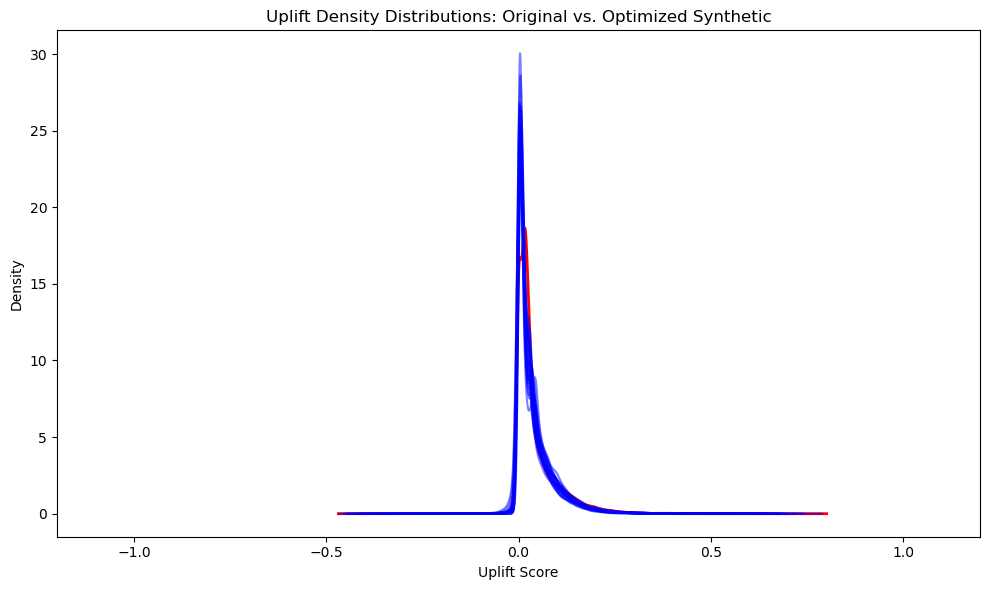

In [184]:
plt.figure(figsize=(10, 6))

pd.Series(uplift_distributions_synthetic["original"]).plot.kde(
    color="red", linewidth=2, label="Original"
)

for col in uplift_distributions_synthetic.columns:
    if col == "original":
        continue
    pd.Series(uplift_distributions_synthetic[col]).plot.kde(
        color="blue", alpha=0.5, linewidth=1.5
    )

plt.title("Uplift Density Distributions: Original vs. Optimized Synthetic")
plt.xlabel("Uplift Score")
plt.ylabel("Density")
plt.xlim(-1.2, 1.2)
# plt.legend()
plt.tight_layout()
plt.show()

Repeat for DP-GAN synthesized data.

In [185]:
uplift_distributions_dp = pd.DataFrame()
uplift_distributions_dp["original"] = uplift_original

In [186]:
for i in range(num_synthetic):
    try:
        syn_df = pd.read_csv("../../Data/Criteo/dpgan_13_" + str(i) + "_train_os.csv")
        # Column alignment
        syn_df = syn_df[original.columns]
        uplift_vals = compute_uplift_distribution(df=syn_df, feature_cols=feature_cols)
        uplift_distributions_dp[f"uplift_{i}"] = uplift_vals
        print(f"Uplift distribution computed for dataset {i}.")
    except:
        print("Can't fit model.")

Uplift distribution computed for dataset 0.
Uplift distribution computed for dataset 1.
Uplift distribution computed for dataset 2.
Uplift distribution computed for dataset 3.
Uplift distribution computed for dataset 4.
Uplift distribution computed for dataset 5.
Uplift distribution computed for dataset 6.
Uplift distribution computed for dataset 7.
Uplift distribution computed for dataset 8.
Uplift distribution computed for dataset 9.
Uplift distribution computed for dataset 10.
Uplift distribution computed for dataset 11.
Uplift distribution computed for dataset 12.
Uplift distribution computed for dataset 13.
Uplift distribution computed for dataset 14.
Uplift distribution computed for dataset 15.
Uplift distribution computed for dataset 16.
Uplift distribution computed for dataset 17.
Uplift distribution computed for dataset 18.
Uplift distribution computed for dataset 19.


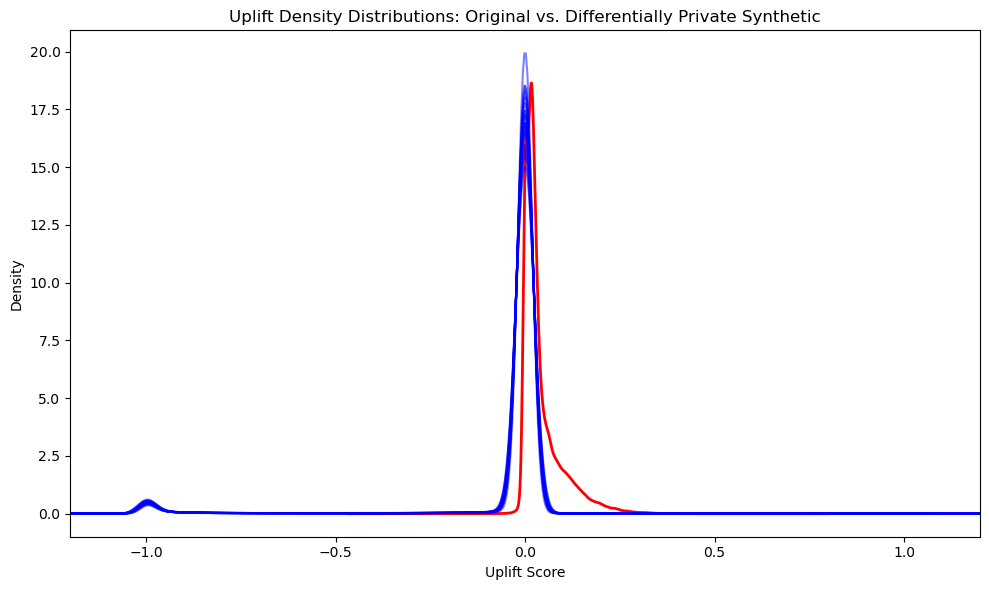

In [187]:
plt.figure(figsize=(10, 6))

pd.Series(uplift_distributions_dp["original"]).plot.kde(
    color="red", linewidth=2, label="Original"
)

for col in uplift_distributions_dp.columns:
    if col == "original":
        continue
    pd.Series(uplift_distributions_dp[col]).plot.kde(
        color="blue", alpha=0.5, linewidth=1.5
    )

plt.title("Uplift Density Distributions: Original vs. Differentially Private Synthetic")
plt.xlabel("Uplift Score")
plt.ylabel("Density")
plt.xlim(-1.2, 1.2)
# plt.legend()
plt.tight_layout()
plt.show()

Compare Distributions: Mean and SD

In [188]:
uplift_distributions_synthetic

,original,uplift_0,uplift_1,uplift_2,uplift_3,uplift_4,uplift_5,uplift_6,uplift_7,uplift_8,uplift_9,uplift_10,uplift_11,uplift_12,uplift_13,uplift_14,uplift_15,uplift_16,uplift_17,uplift_18,uplift_19
0,0.066009,-0.000208,0.037552,0.038792,0.074879,0.027207,0.097166,0.050931,0.125174,0.013151,0.023170,0.032500,0.190755,0.033695,0.122198,0.010045,0.006173,0.045907,0.029123,0.061144,0.010273
1,0.000407,0.008304,0.003861,0.000454,0.127591,0.034947,0.005017,0.105104,0.010349,0.019121,0.021555,0.007496,-0.003542,0.010378,0.033955,0.010556,0.003407,0.003398,0.023952,0.063036,0.090239
2,0.122540,0.102126,0.077273,-0.001409,0.027490,0.001118,0.039720,0.008853,0.015925,0.030380,0.004258,0.099265,0.003757,0.102723,0.004235,0.000991,0.030469,0.004711,0.024705,-0.001321,0.010050
3,0.192770,0.029443,0.015283,0.042964,0.057368,0.006314,0.008190,0.040972,0.060186,0.050506,0.003945,0.047672,0.018924,-0.003559,0.026338,0.000072,0.041182,0.053072,0.016596,0.005807,0.041298
4,0.031641,0.047079,0.008677,0.048509,0.040883,0.008986,0.008346,0.027020,-0.004986,0.038564,0.002416,0.118089,-0.000439,0.123913,0.011070,0.000005,0.013735,0.010020,0.007259,0.052128,0.006164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,0.014249,0.085513,0.287522,0.132854,0.109301,0.007228,0.036655,0.000379,0.059312,-0.001964,0.011275,-0.003458,-0.004569,0.117442,0.004681,0.069111,0.000060,0.008178,0.000282,0.011374,0.054182
61157,0.014181,0.016760,0.044499,0.002731,0.051589,0.034777,0.019186,0.000031,0.020071,0.003858,0.009989,0.049546,0.011739,0.059497,0.032151,0.000001,0.007595,0.008745,0.055899,0.204395,0.020824
61158,0.092623,0.006205,0.012428,-0.001104,0.008554,0.093296,0.042444,0.188338,0.029994,0.002393,0.024278,0.022843,-0.002771,0.142812,0.019300,0.008482,0.015036,0.010010,0.085443,-0.014112,0.002568
61159,0.070125,0.024093,0.011315,0.030147,0.000001,0.019583,0.016888,0.068007,-0.000082,0.014862,0.003968,0.169171,-0.001870,0.012841,0.023915,0.060440,0.044929,0.007209,0.006351,0.011234,0.003583


In [189]:
# mean uplift from original data
uplift_distributions_synthetic.iloc[:,0].mean()

np.float64(0.04116890303909874)

In [190]:
# mean uplift across optimized synthetic data sets
uplift_distributions_synthetic.iloc[:, 1:].mean().mean()

np.float64(0.037088532343590816)

In [191]:
# mean uplift across DP-GAN synthetic data sets
uplift_distributions_dp.iloc[:, 1:].mean().mean()

np.float64(-0.04241793970200965)

Compute out-of-sample uplift predictions using models trained on the synthetic data sets.

In [192]:
def oos_uplift(train_df, test_df, feature_cols = feature_cols, treatment_col="treatment", outcome_col="conversion"):
    
    # split training data into treat and control groups
    treat_df   = train_df[train_df[treatment_col] == 1]
    control_df = train_df[train_df[treatment_col] == 0]

    # create X and y matrices for the treat and control groups
    X_treat   = treat_df[feature_cols]
    y_treat   = treat_df[outcome_col]
    X_control = control_df[feature_cols]
    y_control = control_df[outcome_col]

    # train logistic regression models for conversion on both treat and control groups
    model_t = LogisticRegression(penalty=None, max_iter=1000)
    model_c = LogisticRegression(penalty=None, max_iter=1000)
    model_t.fit(X_treat, y_treat)
    model_c.fit(X_control, y_control)

    # create feature matrix from test dataframe
    X_test = test_df[feature_cols]
    p_t = model_t.predict_proba(X_test)[:, 1]
    p_c = model_c.predict_proba(X_test)[:, 1]

    uplift = p_t - p_c
    return uplift

Compute out of sample uplift using models trained on the confidential training data set.

In [193]:
test_df = original = pd.read_csv("../../Data/Criteo/cleaned_criteo_test_os.gz", 
                       compression='gzip', 
                       sep='\,',
                       header=0,
                       engine='python')

In [194]:
test_df

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,23.647300,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,8.760825,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,0,0,0,0
2,16.057460,10.679513,8.510673,3.359763,10.280525,2.230907,-2.411115,7.370698,3.927254,21.416100,5.300375,-0.168679,1,0,0,0
3,12.618086,11.119309,8.413843,-3.370243,15.019032,-1.703014,-23.207382,6.540114,3.718107,39.483342,5.905930,-0.267350,1,1,1,1
4,13.100168,10.679513,8.242836,-1.118497,16.073060,1.624218,-13.412152,6.170837,3.750806,50.657944,5.472592,-0.802051,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20382,14.038711,10.059654,8.420706,3.359763,10.280525,4.115453,-6.699321,4.833815,3.837301,23.570168,5.300375,-0.168679,1,1,1,0
20383,21.069592,10.059654,8.227045,4.679882,11.973287,4.115453,-6.359690,4.833815,3.819152,28.760224,6.225611,-0.168679,1,1,1,0
20384,12.616365,10.059654,8.647327,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,16.226044,5.300375,-0.168679,1,0,0,0
20385,12.616365,10.059654,8.347506,4.679882,11.029584,4.115453,0.294443,4.833815,3.820594,41.086811,5.513018,-0.267350,1,1,1,0


In [195]:
oos_uplift_original = oos_uplift(train_df=original, test_df=test_df, feature_cols=feature_cols)

Import synthetic data sets from both methods and compute out-of-sample uplift predictions.

In [196]:
oos_uplift_synthetic = pd.DataFrame()
oos_uplift_synthetic["original"] = oos_uplift_original

In [197]:
for i in range(num_synthetic):
    syn_train_df = pd.read_csv("../../Data/Criteo/cart_" + str(i) + "_train_os_uplift.csv")
    # Column alignment
    syn_train_df = syn_train_df[original.columns]
    oos_uplift_vals = oos_uplift(train_df=syn_train_df, test_df=test_df, feature_cols=feature_cols)
    oos_uplift_synthetic[f"uplift_{i}"] = oos_uplift_vals
    print(f"Uplift distribution computed for dataset {i}.")

Uplift distribution computed for dataset 0.
Uplift distribution computed for dataset 1.
Uplift distribution computed for dataset 2.
Uplift distribution computed for dataset 3.
Uplift distribution computed for dataset 4.
Uplift distribution computed for dataset 5.
Uplift distribution computed for dataset 6.
Uplift distribution computed for dataset 7.
Uplift distribution computed for dataset 8.
Uplift distribution computed for dataset 9.
Uplift distribution computed for dataset 10.
Uplift distribution computed for dataset 11.
Uplift distribution computed for dataset 12.
Uplift distribution computed for dataset 13.
Uplift distribution computed for dataset 14.
Uplift distribution computed for dataset 15.
Uplift distribution computed for dataset 16.
Uplift distribution computed for dataset 17.
Uplift distribution computed for dataset 18.
Uplift distribution computed for dataset 19.


Repeat for the DP-GAN synthetic data sets.

In [198]:
oos_uplift_dp = pd.DataFrame()
oos_uplift_dp["original"] = oos_uplift_original

for i in range(num_synthetic):
    dp_train_df = pd.read_csv("../../Data/Criteo/dpgan_13_" + str(i) + "_train_os.csv")
    # Column alignment
    dp_train_df = dp_train_df[original.columns]
    oos_uplift_vals = oos_uplift(train_df=dp_train_df, test_df=test_df, feature_cols=feature_cols)
    oos_uplift_dp[f"uplift_{i}"] = oos_uplift_vals
    print(f"Uplift distribution computed for dataset {i}.")

Uplift distribution computed for dataset 0.
Uplift distribution computed for dataset 1.
Uplift distribution computed for dataset 2.
Uplift distribution computed for dataset 3.
Uplift distribution computed for dataset 4.
Uplift distribution computed for dataset 5.
Uplift distribution computed for dataset 6.
Uplift distribution computed for dataset 7.
Uplift distribution computed for dataset 8.
Uplift distribution computed for dataset 9.
Uplift distribution computed for dataset 10.
Uplift distribution computed for dataset 11.
Uplift distribution computed for dataset 12.
Uplift distribution computed for dataset 13.
Uplift distribution computed for dataset 14.
Uplift distribution computed for dataset 15.
Uplift distribution computed for dataset 16.
Uplift distribution computed for dataset 17.
Uplift distribution computed for dataset 18.
Uplift distribution computed for dataset 19.


Compute test sample uplift ranking. Obtain the indexes of the top 1000 customers ranked on uplift.

In [199]:
targeted = oos_uplift_dp.iloc[:,0].sort_values(ascending=False).index[:1000]

Compute rankings from optimized synthetic data sets.

In [200]:
synthetic_targeted = [oos_uplift_synthetic.iloc[:,i].sort_values(ascending=False).index[:1000] for i in range(1, num_synthetic+1)]

Compute rankings from DP-GAN synthetic data sets.

In [201]:
dp_targeted = [oos_uplift_dp.iloc[:,i].sort_values(ascending=False).index[:1000] for i in range(1, num_synthetic+1)]

Compute the proportion of customers from the baseline target set estimated from the original data that are contained in the target set from each synthetic data set.

In [202]:
synth_props = [(1 - len(targeted.difference(x))/1000) * 100 for x in synthetic_targeted]

In [203]:
dp_props = [(1 - len(targeted.difference(x))/1000) * 100 for x in dp_targeted]

In [204]:
np.mean(synth_props)

np.float64(39.97000000000001)

In [205]:
np.mean(dp_props)

np.float64(1.5350000000000006)

---

Compare Distributions: Wasserstein

In [25]:
cols = uplift_distributions.columns
n = len(cols)
wasserstein_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        wasserstein_matrix[i, j] = wasserstein_distance(uplift_distributions[cols[i]], uplift_distributions[cols[j]])

wasserstein_df = pd.DataFrame(wasserstein_matrix, index=cols, columns=cols)
print(wasserstein_df)

           original  uplift_0  uplift_1  uplift_2  uplift_3  uplift_4  uplift_5  uplift_6  uplift_7  uplift_8  uplift_9  uplift_10  uplift_11  uplift_12  uplift_13  uplift_14  uplift_15  uplift_16  uplift_17  uplift_18  uplift_19
original   0.000000  0.023202  0.025137  0.021850  0.019248  0.023927  0.020414  0.021324  0.022475  0.022201  0.020922   0.022123   0.024047   0.024258   0.024631   0.024861   0.021130   0.021281   0.022696   0.022021   0.019699
uplift_0   0.023202  0.000000  0.010823  0.002817  0.004794  0.006868  0.004573  0.005293  0.005980  0.003559  0.012607   0.003689   0.007952   0.010081   0.010673   0.009887   0.004673   0.007031   0.007455   0.006471   0.007025
uplift_1   0.025137  0.010823  0.000000  0.009015  0.009283  0.004036  0.009027  0.007577  0.006621  0.009487  0.007368   0.009395   0.004393   0.003209   0.003261   0.002174   0.007004   0.004671   0.003822   0.004789   0.006353
uplift_2   0.021850  0.002817  0.009015  0.000000  0.003734  0.005119  0.002521 

**Note that the columns of the synthetic data sets need to be reordered after you import the data so that the order matches that of the original data**.

Real-world use cases driving these analyses?

In-sample measurements: if an advertising company or walled garden were to share the data from a past campaign, could a user obtain reasonable estimates of the uplift from the synthetic data?

Out-of-sample measurements: given the results of a previous campaign, can a model trained on the synthetic data that can give reasonably accurate estimates for uplift for *real* out-of-sample consumers?